# 🔬 Clase 2 — Pasos y tipos del método científico
## Fundamentos del método científico y probabilidad

**Desafío inicial:** Un equipo de salud pública observa que los controles médicos preventivos han disminuido. ¿Cómo estructurar una investigación científica rigurosa, medible y útil para tomar decisiones?

**Objetivos:**
- Aplicar los **9 pasos del método científico** en un proyecto de datos
- Distinguir entre investigación **cualitativa, cuantitativa y mixta**
- Saber elegir el enfoque según el tipo de pregunta y datos disponibles
- Aplicar estos pasos en dos actividades prácticas contextualizadas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

print('✅ Librerías cargadas')

✅ Librerías cargadas


---
## PARTE 1 — Los 9 pasos del método científico

### 1.1 Tabla completa — slides 5-9

In [2]:
# Tabla de los 9 pasos con contexto e-commerce — slides 5 al 9
tabla_pasos = pd.DataFrame({
    'Paso': list(range(1, 10)),
    'Nombre': [
        'Observación',
        'Planteamiento del problema / pregunta',
        'Revisión de antecedentes',
        'Formulación de hipótesis',
        'Diseño del estudio o experimento',
        'Recolección de datos',
        'Análisis de datos',
        'Conclusión',
        'Comunicación y réplica'
    ],
    'Descripción': [
        'Algo llama la atención o rompe con lo esperado.',
        'Transformar la observación en pregunta clara, medible, acotada y relevante.',
        'Explorar estudios previos, benchmarks o experiencias similares.',
        'Afirmación tentativa, falsable, que da una posible explicación.',
        'Qué datos, cómo recolectarlos, qué variables y métodos de análisis.',
        'Extraer, registrar y validar datos con herramientas confiables y trazables.',
        'Técnicas estadísticas para probar hipótesis, identificar patrones.',
        'Interpretar si la hipótesis fue validada o rechazada. Consciente de limitaciones.',
        'Documentar y compartir metodología, datos, decisiones y resultados.'
    ],
    'Ejemplo e-commerce (slides 5-9)': [
        'Caída inesperada en la tasa de conversión durante feriados.',
        '¿Los tiempos de carga afectan la conversión en días de alto tráfico?',
        'Literatura de UX, registros históricos de navegación, benchmarks sectoriales.',
        'Si carga > 4 seg → tasa de conversión disminuye significativamente.',
        'Cruzar tiempos de carga con conversión; controlar dispositivo y horario.',
        'Logs de servidor, Google Analytics, eventos de clic y finalización de compra.',
        'Regresión logística para predecir conversión en función del tiempo de carga.',
        'Carga > 4 seg → caída del 15% en conversión; mayor en usuarios móviles.',
        'Informe técnico + dashboard + código en Jupyter Notebook en repositorio.'
    ]
})
print('=== Los 9 pasos del método científico ===')
print(tabla_pasos.to_string(index=False))

=== Los 9 pasos del método científico ===
 Paso                                Nombre                                                                       Descripción                                               Ejemplo e-commerce (slides 5-9)
    1                           Observación                                   Algo llama la atención o rompe con lo esperado.                   Caída inesperada en la tasa de conversión durante feriados.
    2 Planteamiento del problema / pregunta       Transformar la observación en pregunta clara, medible, acotada y relevante.          ¿Los tiempos de carga afectan la conversión en días de alto tráfico?
    3              Revisión de antecedentes                   Explorar estudios previos, benchmarks o experiencias similares. Literatura de UX, registros históricos de navegación, benchmarks sectoriales.
    4              Formulación de hipótesis                   Afirmación tentativa, falsable, que da una posible explicación.           Si car

In [3]:
# Riesgos al saltarse pasos — slide 10
riesgos = pd.DataFrame({
    'Sin método científico → conclusiones pueden ser:': [
        'Espurias (correlaciones sin causalidad)',
        'Sesgadas (influidas por intuiciones o errores de muestreo)',
        'Irreproducibles (no verificables por otro equipo)',
        'Inútiles (no resuelven el problema real)'
    ]
})
print(riesgos.to_string(index=False))
print()
print('Ejemplo slide 11: analista omite variables confusoras (mayor presencia policial).')
print('  → La correlación cámaras/robos es espuria. La inversión no genera el impacto esperado.')

          Sin método científico → conclusiones pueden ser:
                   Espurias (correlaciones sin causalidad)
Sesgadas (influidas por intuiciones o errores de muestreo)
         Irreproducibles (no verificables por otro equipo)
                  Inútiles (no resuelven el problema real)

Ejemplo slide 11: analista omite variables confusoras (mayor presencia policial).
  → La correlación cámaras/robos es espuria. La inversión no genera el impacto esperado.


### 1.2 Demostración: correlación espuria (cámaras y delitos — slide 11)

C:\Users\Natalie\AppData\Local\Temp\ipykernel_19956\660330404.py:29: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Natalie\AppData\Local\Temp\ipykernel_19956\660330404.py:29: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\Natalie\anaconda3\envs\BootcampCienciaDeDatos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Natalie\anaconda3\envs\BootcampCienciaDeDatos\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


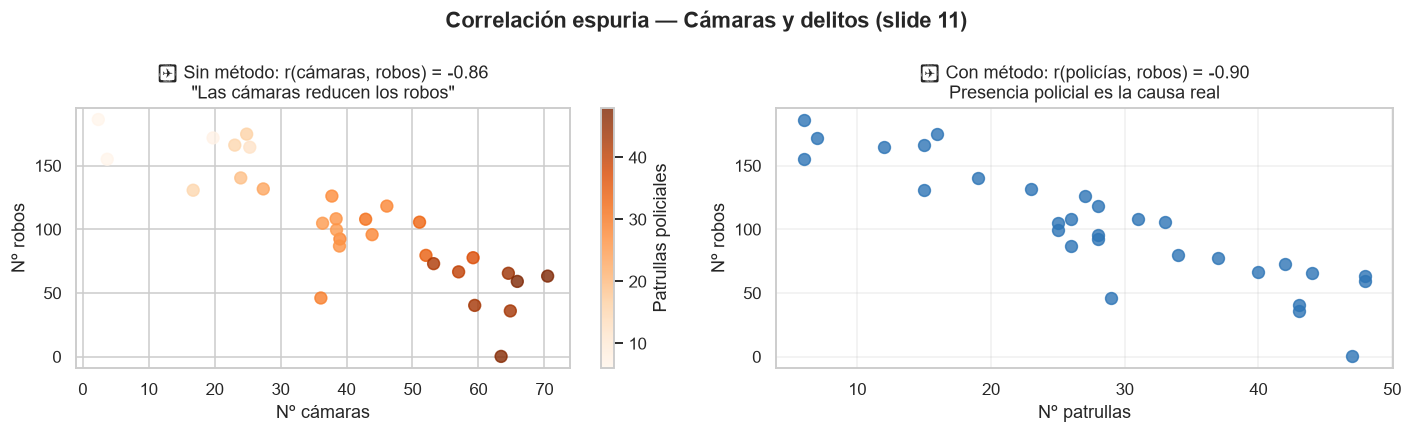

Conclusión: sin controlar variables de confusión, se toma una decisión de inversión errónea.


In [4]:
# Simulación del ejemplo de la municipalidad (slide 11)
np.random.seed(42)
n = 30
# Variable confusora: presencia policial
policia = np.random.randint(5, 50, n)  # nº de patrullas
# Cámaras correlacionadas con presencia policial (se despliegan juntas)
camaras = policia * 1.5 + np.random.normal(0, 5, n)
# Robos disminuyen por POLICIA, no por cámaras
robos   = 200 - policia * 3.5 + np.random.normal(0, 20, n)

r_cam_rob = np.corrcoef(camaras, robos)[0,1]
r_pol_rob = np.corrcoef(policia, robos)[0,1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Correlación espuria — Cámaras y delitos (slide 11)', fontweight='bold')

sc1 = axes[0].scatter(camaras, robos, c=policia, cmap='Oranges', s=60, alpha=0.8)
plt.colorbar(sc1, ax=axes[0], label='Patrullas policiales')
axes[0].set_title(f'❌ Sin método: r(cámaras, robos) = {r_cam_rob:.2f}\n"Las cámaras reducen los robos"')
axes[0].set_xlabel('Nº cámaras')
axes[0].set_ylabel('Nº robos')

axes[1].scatter(policia, robos, color='#2E75B6', s=60, alpha=0.8)
axes[1].set_title(f'✅ Con método: r(policías, robos) = {r_pol_rob:.2f}\nPresencia policial es la causa real')
axes[1].set_xlabel('Nº patrullas')
axes[1].set_ylabel('Nº robos')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print('Conclusión: sin controlar variables de confusión, se toma una decisión de inversión errónea.')

### ✏️ Ejercicio 1 — Aplica los pasos al desafío inicial:

In [5]:
# Desafío: disminución de controles médicos preventivos en APS
# ✏️ Completa los 9 pasos para este caso:

diseno_aps = {
    1: {'Observación':              ''},
    2: {'Pregunta':                 ''},
    3: {'Antecedentes':             ''},
    4: {'Hipótesis':                ''},
    5: {'Diseño':                   ''},
    6: {'Recolección de datos':     ''},
    7: {'Análisis':                 ''},
    8: {'Conclusión':               ''},
    9: {'Comunicación':             ''},
}

print('--- DISEÑO DE INVESTIGACIÓN: CONTROLES MÉDICOS APS ---')
for paso, contenido in diseno_aps.items():
    nombre, resp = list(contenido.items())[0]
    print(f'{paso}. {nombre}: {resp}')

--- DISEÑO DE INVESTIGACIÓN: CONTROLES MÉDICOS APS ---
1. Observación: 
2. Pregunta: 
3. Antecedentes: 
4. Hipótesis: 
5. Diseño: 
6. Recolección de datos: 
7. Análisis: 
8. Conclusión: 
9. Comunicación: 


---
## PARTE 2 — Métodos de investigación: cualitativo, cuantitativo y mixto

### 2.1 Tabla comparativa completa — slide 15

In [6]:
# Tabla slide 15
tabla_metodos = pd.DataFrame({
    'Elemento': [
        'Finalidad principal',
        'Tipo de datos',
        'Técnicas comunes',
        'Muestra',
        'Análisis',
        'Resultados esperados'
    ],
    'Investigación Cuantitativa': [
        'Medir, probar, predecir',
        'Números, métricas, escalas',
        'Encuestas, experimentos, modelado estadístico',
        'Representativa y numerosa',
        'Estadístico, inferencial',
        'Generalizables, comparables'
    ],
    'Investigación Cualitativa': [
        'Comprender, explorar, interpretar',
        'Textos, discursos, observaciones',
        'Entrevistas, grupos focales, análisis narrativo',
        'Intencional y reducida',
        'Categorial, temático, inductivo',
        'Profundos, contextualizados'
    ]
})
print('=== Comparativa: Cuantitativa vs Cualitativa (slide 15) ===')
print(tabla_metodos.to_string(index=False))

=== Comparativa: Cuantitativa vs Cualitativa (slide 15) ===
            Elemento                    Investigación Cuantitativa                       Investigación Cualitativa
 Finalidad principal                       Medir, probar, predecir               Comprender, explorar, interpretar
       Tipo de datos                    Números, métricas, escalas                Textos, discursos, observaciones
    Técnicas comunes Encuestas, experimentos, modelado estadístico Entrevistas, grupos focales, análisis narrativo
             Muestra                     Representativa y numerosa                          Intencional y reducida
            Análisis                      Estadístico, inferencial                 Categorial, temático, inductivo
Resultados esperados                   Generalizables, comparables                     Profundos, contextualizados


In [7]:
# Tabla de aplicación al ciclo de ciencia de datos — slide 18
tabla_ciclo = pd.DataFrame({
    'Paso del proceso científico': [
        'Observación',
        'Hipótesis',
        'Recolección de datos',
        'Análisis'
    ],
    'Aplicación cualitativa': [
        'Entrevistas abiertas a usuarios/as',
        'Ideas emergentes del discurso',
        'Diario de campo, transcripciones',
        'Codificación temática de discursos'
    ],
    'Aplicación cuantitativa': [
        'Análisis exploratorio de logs de uso',
        'Proposición estadística contrastable',
        'Datos estructurados, sensores, bases numéricas',
        'Modelos de regresión, test estadísticos'
    ]
})
print('=== Cuantitativo vs Cualitativo en el ciclo de análisis (slide 18) ===')
print(tabla_ciclo.to_string(index=False))

=== Cuantitativo vs Cualitativo en el ciclo de análisis (slide 18) ===
Paso del proceso científico             Aplicación cualitativa                        Aplicación cuantitativa
                Observación Entrevistas abiertas a usuarios/as           Análisis exploratorio de logs de uso
                  Hipótesis      Ideas emergentes del discurso           Proposición estadística contrastable
       Recolección de datos   Diario de campo, transcripciones Datos estructurados, sensores, bases numéricas
                   Análisis Codificación temática de discursos        Modelos de regresión, test estadísticos


In [8]:
# Criterios para elegir el enfoque — slide 16
criterios = pd.DataFrame({
    'Criterio': [
        'Tipo de pregunta',
        'Datos disponibles',
        'Objetivo del estudio',
        'Contexto institucional'
    ],
    '→ Cuantitativo si…': [
        '¿Cuánto? ¿Con qué frecuencia? ¿Qué diferencia?',
        'Registros estructurados, métricas, logs',
        'Medir magnitud, generalizar, predecir',
        'Requiere datos auditables y comparables'
    ],
    '→ Cualitativo si…': [
        '¿Por qué? ¿Cómo se vive? ¿Qué significa?',
        'Textos, entrevistas, observaciones',
        'Comprender causas, explorar experiencias',
        'Necesita profundidad y contexto subjetivo'
    ]
})
print('=== Criterios para elegir el enfoque (slide 16) ===')
print(criterios.to_string(index=False))

=== Criterios para elegir el enfoque (slide 16) ===
              Criterio                             → Cuantitativo si…                         → Cualitativo si…
      Tipo de pregunta ¿Cuánto? ¿Con qué frecuencia? ¿Qué diferencia?  ¿Por qué? ¿Cómo se vive? ¿Qué significa?
     Datos disponibles        Registros estructurados, métricas, logs        Textos, entrevistas, observaciones
  Objetivo del estudio          Medir magnitud, generalizar, predecir  Comprender causas, explorar experiencias
Contexto institucional        Requiere datos auditables y comparables Necesita profundidad y contexto subjetivo


### ✏️ Ejercicio 2 — Clasifica el enfoque correcto:

In [9]:
# ✏️ Asigna el enfoque más adecuado (Cuantitativo/Cualitativo/Mixto) a cada problema:
casos_enfoque = {
    '¿Cuántos usuarios abandonan el registro antes del paso 3?':            '',
    '¿Por qué los beneficiarios no asisten a los talleres presenciales?':   '',
    '¿Hay diferencia en ventas entre regiones Norte y Sur?':                '',
    '¿Cómo viven las madres trabajadoras la conciliación laboral?':         '',
    '¿Qué logros de curso predicen mejor la nota final?':                   '',
    '¿Qué sienten los estudiantes cuando reprueben un módulo?':             '',
}

print('--- CLASIFICACIÓN DE ENFOQUES ---')
for caso, enfoque in casos_enfoque.items():
    print(f'\nPregunta: {caso}')
    print(f'  Enfoque: {enfoque}')

# ✏️ Preguntas de reflexión:
# ¿Cuál es la diferencia clave entre enfoque cuantitativo y cualitativo? (cierre 2)
c2 = ""
# ¿Por qué el enfoque mixto puede ser más útil en ciencia de datos? (cierre 5)
c5 = ""

print(f'\nDiferencia: {c2}')
print(f'Mixto útil: {c5}')

--- CLASIFICACIÓN DE ENFOQUES ---

Pregunta: ¿Cuántos usuarios abandonan el registro antes del paso 3?
  Enfoque: 

Pregunta: ¿Por qué los beneficiarios no asisten a los talleres presenciales?
  Enfoque: 

Pregunta: ¿Hay diferencia en ventas entre regiones Norte y Sur?
  Enfoque: 

Pregunta: ¿Cómo viven las madres trabajadoras la conciliación laboral?
  Enfoque: 

Pregunta: ¿Qué logros de curso predicen mejor la nota final?
  Enfoque: 

Pregunta: ¿Qué sienten los estudiantes cuando reprueben un módulo?
  Enfoque: 

Diferencia: 
Mixto útil: 


---
## PARTE 3 — Actividad guiada: App móvil (slides 19-22)

### 3.1 Cargar datos

In [10]:
df_app = pd.read_csv('app_movil_metricas.csv')
print(f'Registros: {df_app.shape}')
print(df_app.head(8))
print()
print(df_app.describe().round(2))

Registros: (150, 9)
  id_usuario dispositivo  version_app  tiempo_carga_seg  duracion_sesion_seg  \
0      U0001     Android  2.3 (nueva)              3.68                  108   
1      U0002   HarmonyOS  2.3 (nueva)              4.10                  262   
2      U0003     Android  2.3 (nueva)              4.52                  571   
3      U0004     Android  2.3 (nueva)              5.07                  171   
4      U0005     Android          2.1              3.53                  310   
5      U0006         iOS          2.2              5.03                   45   
6      U0007     Android          2.2              1.03                  282   
7      U0008     Android          2.2              1.84                  313   

   tasa_rebote  paso_abandono_registro  registro_completado  nps  
0        0.328                       3                    0    2  
1        0.600                       2                    0    4  
2        0.590                       3                    

### 3.2 Aplicar los 9 pasos al caso de la app

In [11]:
# Paso 1: Observación con datos reales
print('=== PASO 1 — Observación ===')
print('Situación: nueva versión 2.3 con quejas de lentitud y abandono en registro.')
print()
print('Tasa de rebote por versión:')
print(df_app.groupby('version_app')['tasa_rebote'].mean().round(3))
print()
print('Tiempo de carga promedio por versión:')
print(df_app.groupby('version_app')['tiempo_carga_seg'].mean().round(2))

=== PASO 1 — Observación ===
Situación: nueva versión 2.3 con quejas de lentitud y abandono en registro.

Tasa de rebote por versión:
version_app
2.1            0.389
2.2            0.350
2.3 (nueva)    0.491
Name: tasa_rebote, dtype: float64

Tiempo de carga promedio por versión:
version_app
2.1            3.05
2.2            2.52
2.3 (nueva)    4.47
Name: tiempo_carga_seg, dtype: float64


In [12]:
# Pasos 2-4: Pregunta, hipótesis y diseño
pregunta_app    = "¿Los tiempos de carga superiores a 4 seg en la versión 2.3 explican la mayor tasa de abandono en el registro?"
hipotesis_app   = "Si tiempo_carga_seg > 4 → tasa de rebote aumenta significativamente en la v2.3"
variables_app   = {
    'dependiente':      'registro_completado (0/1)',
    'independiente':    'tiempo_carga_seg',
    'control':          'dispositivo, version_app'
}

print('=== PASOS 2-4: Pregunta, hipótesis, diseño ===')
print(f'Pregunta:    {pregunta_app}')
print(f'Hipótesis:   {hipotesis_app}')
print(f'Variables:   {variables_app}')

=== PASOS 2-4: Pregunta, hipótesis, diseño ===
Pregunta:    ¿Los tiempos de carga superiores a 4 seg en la versión 2.3 explican la mayor tasa de abandono en el registro?
Hipótesis:   Si tiempo_carga_seg > 4 → tasa de rebote aumenta significativamente en la v2.3
Variables:   {'dependiente': 'registro_completado (0/1)', 'independiente': 'tiempo_carga_seg', 'control': 'dispositivo, version_app'}


=== PASOS 5-7: Análisis exploratorio ===


C:\Users\Natalie\AppData\Local\Temp\ipykernel_19956\3339697057.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_app, x='version_app', y='tiempo_carga_seg',


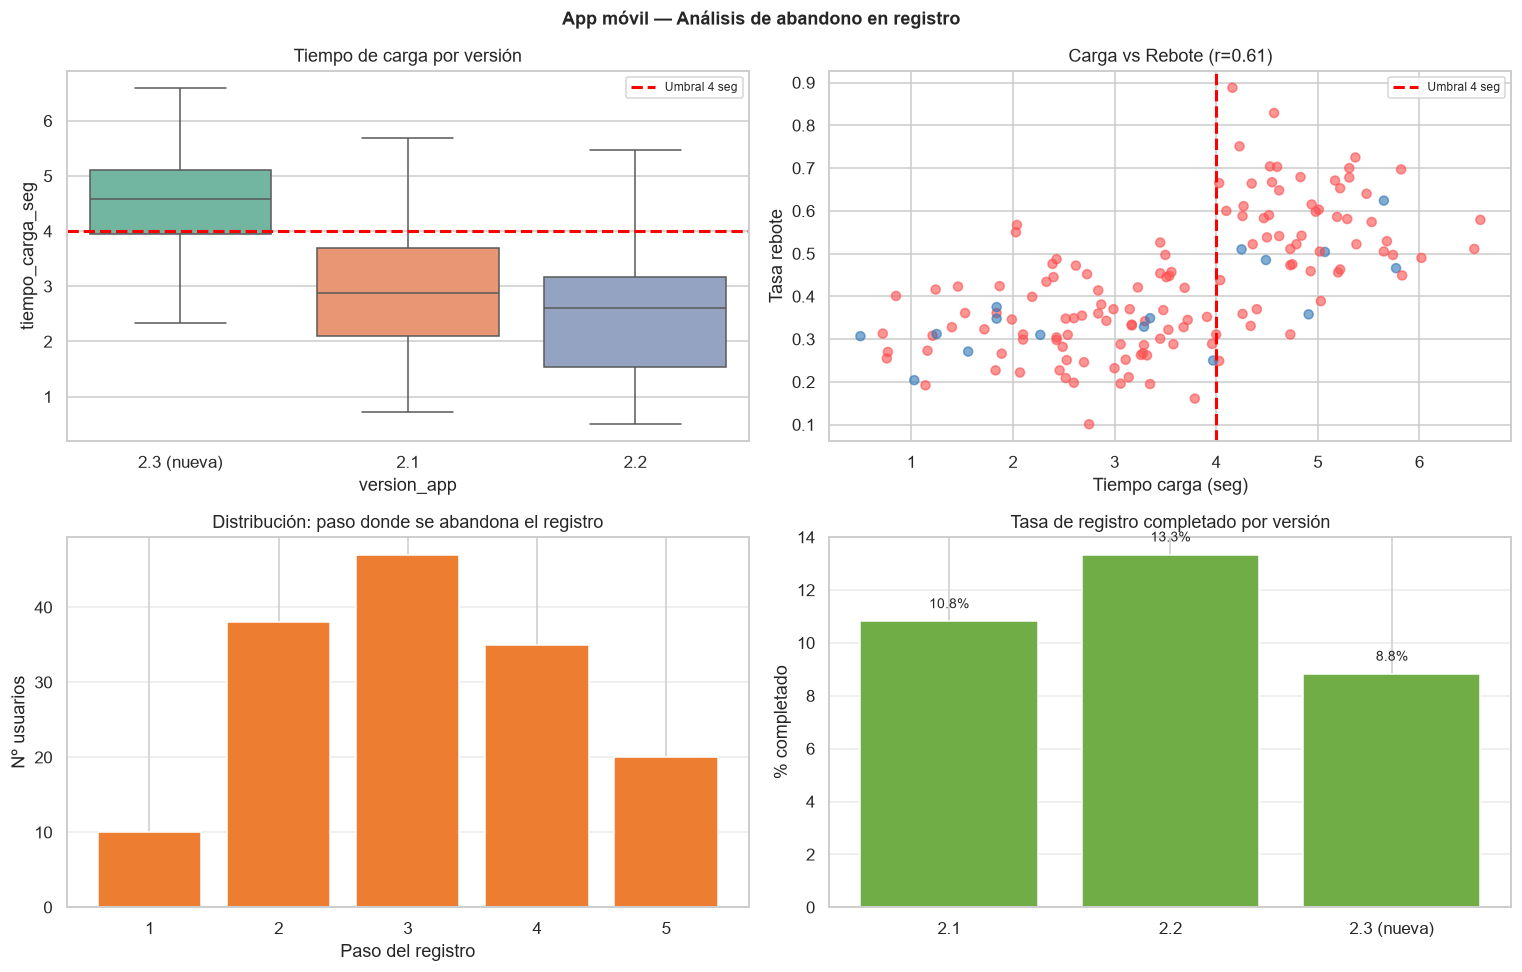

In [13]:
# Pasos 5-7: Diseño del estudio + análisis
print('=== PASOS 5-7: Análisis exploratorio ===')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('App móvil — Análisis de abandono en registro', fontweight='bold', fontsize=12)

# Tiempo de carga por versión
sns.boxplot(data=df_app, x='version_app', y='tiempo_carga_seg',
            palette='Set2', ax=axes[0,0])
axes[0,0].axhline(4, color='red', linestyle='--', linewidth=2, label='Umbral 4 seg')
axes[0,0].set_title('Tiempo de carga por versión')
axes[0,0].legend(fontsize=8)

# Tasa de rebote vs tiempo de carga
axes[0,1].scatter(df_app['tiempo_carga_seg'], df_app['tasa_rebote'],
                   c=df_app['registro_completado'].map({0:'#FC4E4E',1:'#2E75B6'}),
                   alpha=0.6, s=35)
axes[0,1].axvline(4, color='red', linestyle='--', linewidth=2, label='Umbral 4 seg')
axes[0,1].set_title(f'Carga vs Rebote (r={df_app["tiempo_carga_seg"].corr(df_app["tasa_rebote"]):.2f})')
axes[0,1].set_xlabel('Tiempo carga (seg)')
axes[0,1].set_ylabel('Tasa rebote')
axes[0,1].legend(fontsize=8)

# Paso de abandono
conteo_paso = df_app['paso_abandono_registro'].value_counts().sort_index()
axes[1,0].bar(conteo_paso.index, conteo_paso.values, color='#ED7D31', edgecolor='white')
axes[1,0].set_title('Distribución: paso donde se abandona el registro')
axes[1,0].set_xlabel('Paso del registro')
axes[1,0].set_ylabel('Nº usuarios')
axes[1,0].grid(True, axis='y', alpha=0.4)

# Registro completado por versión
tasa_reg = df_app.groupby('version_app')['registro_completado'].mean() * 100
axes[1,1].bar(tasa_reg.index, tasa_reg.values, color='#70AD47', edgecolor='white')
axes[1,1].set_title('Tasa de registro completado por versión')
axes[1,1].set_ylabel('% completado')
axes[1,1].grid(True, axis='y', alpha=0.4)
for i, (v, val) in enumerate(tasa_reg.items()):
    axes[1,1].text(i, val+0.5, f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [14]:
# Pasos 8-9: Conclusión y comunicación
media_carga_v23 = df_app[df_app['version_app']=='2.3 (nueva)']['tiempo_carga_seg'].mean()
pct_sobre_4    = (df_app['tiempo_carga_seg'] > 4).mean() * 100
tasa_reg_v23   = df_app[df_app['version_app']=='2.3 (nueva)']['registro_completado'].mean() * 100

print('=== PASO 8 — Conclusión ===')
print(f'Tiempo de carga promedio v2.3: {media_carga_v23:.2f} seg')
print(f'Usuarios con carga > 4 seg:    {pct_sobre_4:.1f}%')
print(f'Tasa registro completado v2.3: {tasa_reg_v23:.1f}%')
print()
print('=== PASO 9 — Comunicación ===')
print('Recomendaciones para el equipo de desarrollo:')
print('  1. Optimizar tiempo de carga en v2.3 (actualmente >4 seg en varios usuarios)')
print('  2. Rediseñar el paso 3 del registro (mayor abandono según datos)')
print('  3. Priorizar mejoras en Android (mayor proporción de usuarios afectados)')

=== PASO 8 — Conclusión ===
Tiempo de carga promedio v2.3: 4.47 seg
Usuarios con carga > 4 seg:    40.7%
Tasa registro completado v2.3: 8.8%

=== PASO 9 — Comunicación ===
Recomendaciones para el equipo de desarrollo:
  1. Optimizar tiempo de carga en v2.3 (actualmente >4 seg en varios usuarios)
  2. Rediseñar el paso 3 del registro (mayor abandono según datos)
  3. Priorizar mejoras en Android (mayor proporción de usuarios afectados)


### 3.3 Plantilla editable — instrucciones slides 22-23

In [15]:
# ✏️ Plantilla editable — completa para presentar al grupo
plantilla_guiada = {
    'Pregunta de investigación':      pregunta_app,
    'Enfoque metodológico':           'Cuantitativo (principalmente) + Cualitativo (entrevistas de validación)',
    'Justificación del enfoque':      '',   # ← completa
    'Hipótesis':                      hipotesis_app,
    'Variable dependiente':           variables_app['dependiente'],
    'Variables independientes':       variables_app['independiente'],
    'Variables de control':           variables_app['control'],
    'Técnica de recolección':         '',   # ← completa
    'Tipo de análisis previsto':      '',   # ← completa
    '¿Cómo garantizar reproducibilidad?': '',  # ← completa
}

print('═'*65)
print('  PLANTILLA ACTIVIDAD GUIADA — APP MÓVIL')
print('═'*65)
for campo, valor in plantilla_guiada.items():
    print(f'\n{campo}:')
    print(f'  {valor}')
print('═'*65)

═════════════════════════════════════════════════════════════════
  PLANTILLA ACTIVIDAD GUIADA — APP MÓVIL
═════════════════════════════════════════════════════════════════

Pregunta de investigación:
  ¿Los tiempos de carga superiores a 4 seg en la versión 2.3 explican la mayor tasa de abandono en el registro?

Enfoque metodológico:
  Cuantitativo (principalmente) + Cualitativo (entrevistas de validación)

Justificación del enfoque:
  

Hipótesis:
  Si tiempo_carga_seg > 4 → tasa de rebote aumenta significativamente en la v2.3

Variable dependiente:
  registro_completado (0/1)

Variables independientes:
  tiempo_carga_seg

Variables de control:
  dispositivo, version_app

Técnica de recolección:
  

Tipo de análisis previsto:
  

¿Cómo garantizar reproducibilidad?:
  
═════════════════════════════════════════════════════════════════


---
## PARTE 4 — Actividad autónoma: Cursos online (slides 23-27)

### 4.1 Cargar datos

In [16]:
df_cur = pd.read_csv('cursos_online.csv')
print(f'Registros: {df_cur.shape}')
print(df_cur.head(8))
print()
print(f'Tasa de finalización: {df_cur["completado"].mean()*100:.1f}%')

Registros: (200, 10)
  id_estudiante              curso       nivel  mes_inicio  semanas_activo  \
0       EST0001    ML Introducción  Intermedio          11              11   
1       EST0002  Análisis de Datos      Básico           2               9   
2       EST0003       SQL Avanzado      Básico           5               3   
3       EST0004  Análisis de Datos  Intermedio           6               4   
4       EST0005    ML Introducción    Avanzado           2               6   
5       EST0006       SQL Avanzado    Avanzado           3               8   
6       EST0007       SQL Avanzado  Intermedio           5               6   
7       EST0008       SQL Avanzado  Intermedio           9               4   

   sesiones_completadas  pct_avance  completado       motivo_abandono  \
0                    12        38.6           0  dificultad_contenido   
1                    14        59.8           0  dificultad_contenido   
2                     6        91.4           0          

C:\Users\Natalie\AppData\Local\Temp\ipykernel_19956\3098653900.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cur, x='nivel', y='pct_avance',


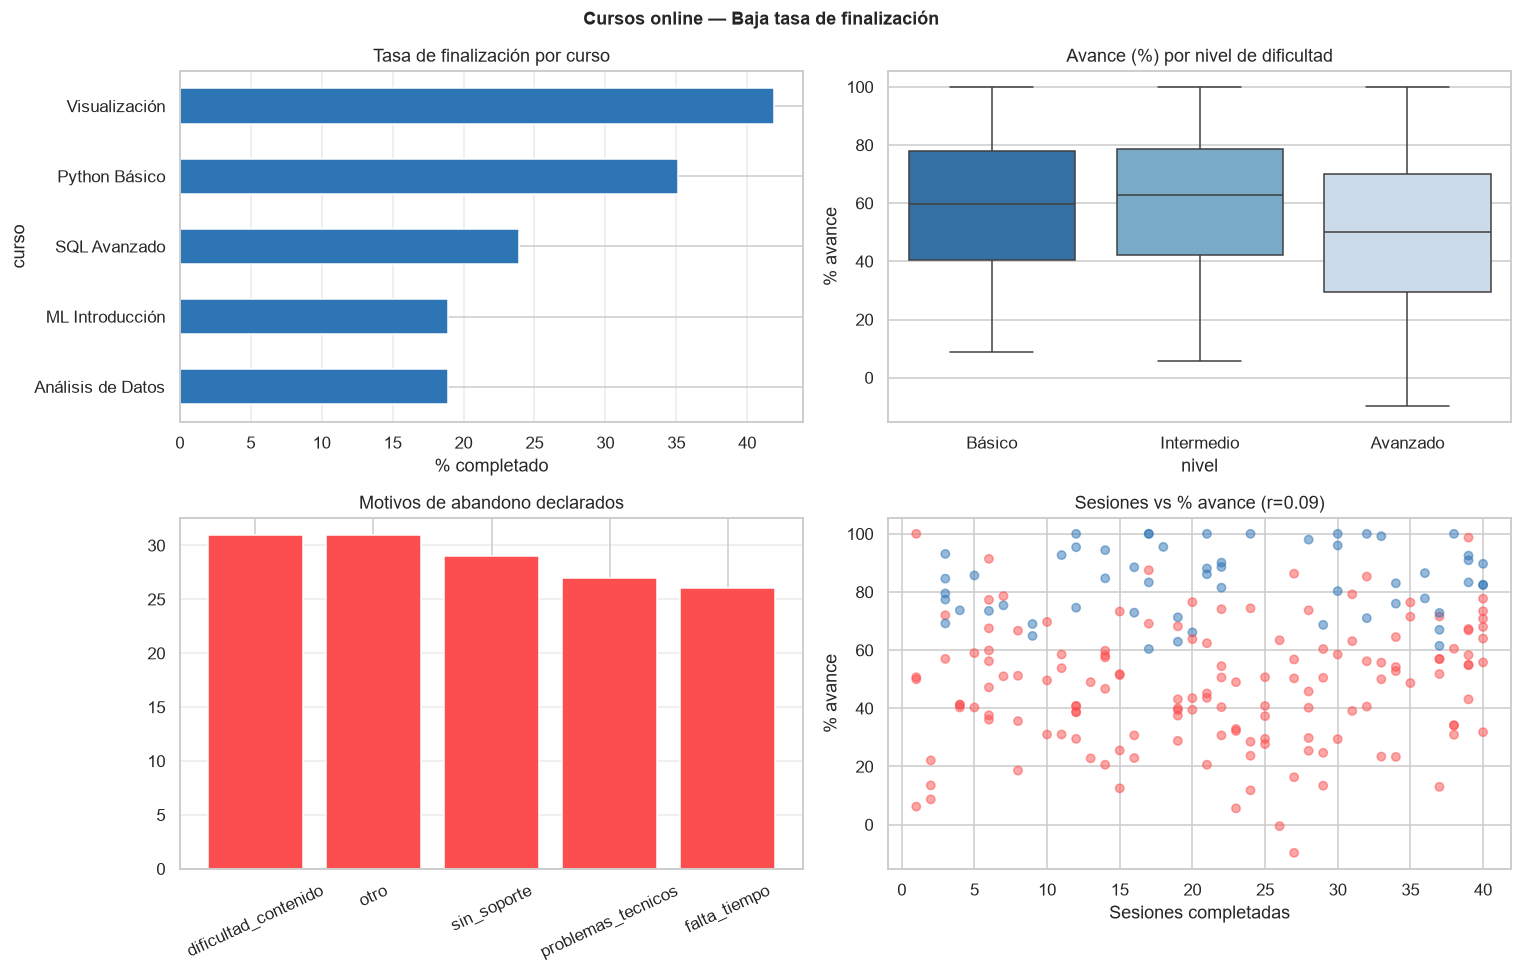

In [17]:
# Exploración inicial
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Cursos online — Baja tasa de finalización', fontweight='bold', fontsize=12)

# Completado por curso
tasa_curso = df_cur.groupby('curso')['completado'].mean() * 100
tasa_curso.sort_values().plot(kind='barh', ax=axes[0,0], color='#2E75B6', edgecolor='white')
axes[0,0].set_title('Tasa de finalización por curso')
axes[0,0].set_xlabel('% completado')
axes[0,0].grid(True, axis='x', alpha=0.4)

# % avance por nivel
sns.boxplot(data=df_cur, x='nivel', y='pct_avance',
            order=['Básico','Intermedio','Avanzado'],
            palette='Blues_r', ax=axes[0,1])
axes[0,1].set_title('Avance (%) por nivel de dificultad')
axes[0,1].set_ylabel('% avance')

# Motivos de abandono
abandono = df_cur[df_cur['completado']==0]['motivo_abandono'].value_counts()
axes[1,0].bar(abandono.index, abandono.values, color='#FC4E4E', edgecolor='white')
axes[1,0].set_title('Motivos de abandono declarados')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=25)
axes[1,0].grid(True, axis='y', alpha=0.4)

# Sesiones completadas vs avance
axes[1,1].scatter(df_cur['sesiones_completadas'], df_cur['pct_avance'],
                   c=df_cur['completado'].map({0:'#FC4E4E',1:'#2E75B6'}),
                   alpha=0.5, s=30)
r_ses = df_cur['sesiones_completadas'].corr(df_cur['pct_avance'])
axes[1,1].set_title(f'Sesiones vs % avance (r={r_ses:.2f})')
axes[1,1].set_xlabel('Sesiones completadas')
axes[1,1].set_ylabel('% avance')

plt.tight_layout()
plt.show()

### 4.2 Tabla de síntesis — slide 27

In [18]:
# ✏️ Completa la tabla de síntesis del slide 27
tabla_sintesis = pd.DataFrame({
    'Elemento': [
        'Pregunta de investigación',
        'Enfoque metodológico',
        'Justificación del enfoque',
        'Hipótesis (si aplica)',
        'Técnica de recolección',
        'Tipo de análisis'
    ],
    'Elección/Descripción': [
        '',   # ✏️
        '',   # ✏️ Cuantitativo / Cualitativo / Mixto
        '',   # ✏️
        '',   # ✏️
        '',   # ✏️ encuesta / entrevista / logs / etc.
        ''    # ✏️ regresión / análisis temático / etc.
    ]
})

print('=== TABLA DE SÍNTESIS (slide 27) ===')
print(tabla_sintesis.to_string(index=False))

=== TABLA DE SÍNTESIS (slide 27) ===
                 Elemento Elección/Descripción
Pregunta de investigación                     
     Enfoque metodológico                     
Justificación del enfoque                     
    Hipótesis (si aplica)                     
   Técnica de recolección                     
         Tipo de análisis                     


In [19]:
# Datos de apoyo para decidir el enfoque
print('=== Datos para apoyar tus decisiones metodológicas ===')
print(f'Tasa global de finalización: {df_cur["completado"].mean()*100:.1f}%')
print()
print('Tasa por nivel:')
print(df_cur.groupby('nivel')['completado'].mean().mul(100).round(1).to_string())
print()
print('Top motivos de abandono:')
print(df_cur[df_cur['completado']==0]['motivo_abandono'].value_counts().to_string())
print()
print('¿Cuáles variables numéricas correlacionan con completar el curso?')
for v in ['sesiones_completadas','semanas_activo','pct_avance','promedio_nota']:
    r = df_cur[v].corr(df_cur['completado'])
    print(f'  {v:<25}: r = {r:.3f}')

=== Datos para apoyar tus decisiones metodológicas ===
Tasa global de finalización: 28.0%

Tasa por nivel:
nivel
Avanzado      16.1
Básico        29.5
Intermedio    36.4

Top motivos de abandono:
motivo_abandono
dificultad_contenido    31
otro                    31
sin_soporte             29
problemas_tecnicos      27
falta_tiempo            26

¿Cuáles variables numéricas correlacionan con completar el curso?
  sesiones_completadas     : r = 0.012
  semanas_activo           : r = 0.017
  pct_avance               : r = 0.657
  promedio_nota            : r = 0.047


### ✏️ Preguntas de cierre — slide 30:

In [20]:
# ✏️ Responde las 5 preguntas de cierre del slide 30

p1 = ""  # ¿Cuáles son los 9 pasos y qué propósito cumple cada uno?
p2 = ""  # ¿Diferencia entre enfoque cualitativo y cuantitativo?
p3 = ""  # ¿Qué criterios ayudan a decidir el enfoque?
p4 = ""  # ¿Cómo se articula el método científico con la ciencia de datos?
p5 = ""  # ¿Por qué es valioso combinar métodos cualitativos y cuantitativos?

preguntas = [
    '¿Cuáles son los pasos del método científico y qué propósito cumple cada uno?',
    '¿Qué diferencia a un enfoque de investigación cualitativo de uno cuantitativo?',
    '¿Qué criterios pueden ayudarte a decidir qué enfoque usar en un estudio?',
    '¿Cómo se articula el método científico con los procesos reales de ciencia de datos?',
    '¿Por qué sería valioso combinar métodos cualitativos y cuantitativos en un mismo proyecto?'
]

print('--- PREGUNTAS DE CIERRE (slide 30) ---')
for i, (preg, resp) in enumerate(zip(preguntas, [p1,p2,p3,p4,p5]), 1):
    print(f'\n{i}. {preg}')
    print(f'   R: {resp}')

--- PREGUNTAS DE CIERRE (slide 30) ---

1. ¿Cuáles son los pasos del método científico y qué propósito cumple cada uno?
   R: 

2. ¿Qué diferencia a un enfoque de investigación cualitativo de uno cuantitativo?
   R: 

3. ¿Qué criterios pueden ayudarte a decidir qué enfoque usar en un estudio?
   R: 

4. ¿Cómo se articula el método científico con los procesos reales de ciencia de datos?
   R: 

5. ¿Por qué sería valioso combinar métodos cualitativos y cuantitativos en un mismo proyecto?
   R: 


---
## 📋 Resumen

### Los 9 pasos del método científico

| # | Paso | Pregunta clave |
|---|------|----------------|
| 1 | Observación | ¿Qué llama la atención o rompe con lo esperado? |
| 2 | Planteamiento del problema | ¿Cuál es la pregunta medible y acotada? |
| 3 | Revisión de antecedentes | ¿Qué se sabe ya sobre esto? |
| 4 | Formulación de hipótesis | ¿Qué afirmación falsable voy a probar? |
| 5 | Diseño del estudio | ¿Qué datos y cómo los analizaré? |
| 6 | Recolección de datos | ¿Cómo extraigo y valido los datos? |
| 7 | Análisis | ¿Qué técnicas aplicaré para probar la hipótesis? |
| 8 | Conclusión | ¿Se validó o rechazó la hipótesis? |
| 9 | Comunicación y réplica | ¿Cómo comparto y documento todo el proceso? |

### Elegir el enfoque correcto

| Señal | Enfoque sugerido |
|-------|------------------|
| Pregunta **¿cuánto? ¿qué diferencia?** | Cuantitativo |
| Pregunta **¿por qué? ¿cómo se experimenta?** | Cualitativo |
| Necesito **medir y también comprender** | Mixto |
| Datos numéricos estructurados disponibles | Cuantitativo |
| Solo textos, discursos, experiencias | Cualitativo |

> 💡 **El enfoque mixto** no es "hacer un poco de cada uno". Es integrar planificadamente ambas perspectivas: generar hipótesis desde lo cualitativo y validarlas con lo cuantitativo, o enriquecer resultados numéricos con contexto narrativo.

> 💡 **Correlación ≠ Causalidad.** El paso 5 (diseño del estudio) es donde se define el control de variables confusoras. Si se omite, las conclusiones del paso 8 serán espurias.